# Case-01：一次靜不定梁 (Propped Cantilever Beam)

**課程第一步**——slope_deflection_framework 專案的起點。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 單跨梁，A端固定、B端滾支承 |
| 跨度 | L = 6.0 m |
| 載重 | 均佈載重 w = 20.0 kN/m (向下) |
| 靜不定度 | 1 (只有一個未知量 θ_B) |
| 邊界條件 | θ_A=0 (固定端不轉動)，M_BA=0 (滾支承不傳彎矩) |

## FEM 慣例
近端負、遠端正（傳統教科書慣例），順時針為正。跟 Case-03 統一。

## 驗證方式
結構受力圖 → 剪力圖(SFD) → 彎矩圖(BMD)，並跟 anastruct 逐一比對、做剪力交叉檢查。

## 0. 安裝套件

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


## 1. 框架本體 (與其他 Case 共用，不因結構而變)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod

sp.init_printing()

# ============================================================
# 環境偵測：同一份程式碼要能在 Jupyter/Colab (有 IPython kernel，
# display()/plt.show() 都能正常渲染) 跟純終端機/VSCode直接執行
# (python3 xxx.py，沒有IPython kernel，display()只會印物件repr、
# plt.show()在沒有視窗系統時什麼都不會顯示) 兩種環境都正常運作。
# ============================================================
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    IN_NOTEBOOK = _ipy is not None and hasattr(_ipy, 'kernel')
except ImportError:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    from IPython.display import Markdown, display
else:
    class Markdown:
        """純終端機環境用的Markdown替代品：只存文字，print時原樣印出
        (不渲染標題#、粗體**這些語法，但內容完整可讀)。"""
        def __init__(self, text):
            self.text = text

    def display(obj):
        """純終端機環境用的display()替代品："""
        if isinstance(obj, Markdown):
            print(obj.text)
        elif isinstance(obj, sp.Basic):
            sp.pprint(obj)
        else:
            print(obj)

_fig_counter = [0]


def _show_fig(prefix="figure"):
    """
    取代裸的 plt.show()：Jupyter/Colab 環境正常顯示；純終端機環境沒有
    畫面可以顯示，改成存檔到當前目錄並印出檔名，不會讓圖「憑空消失」。
    """
    if IN_NOTEBOOK:
        plt.show()
    else:
        _fig_counter[0] += 1
        fname = f"{prefix}_{_fig_counter[0]}.png"
        plt.gcf().savefig(fname, dpi=110, bbox_inches='tight')
        print(f"[圖已存檔: {fname}]")
        plt.close()


# ============================================================
# 通用互動輸入：只用 input()，不依賴 ipywidgets 這種只有特定 notebook
# 環境才有的東西——Colab、純 Linux 終端機(python3 xxx.py)、VSCode
# (不管是 Jupyter 分頁還是直接跑 .py 檔) 全部都能動。
# ============================================================
def prompt_for_params(param_specs):
    """
    param_specs: list of (name, description, default, type_cast)
    互動詢問每個參數，直接按 Enter 就用預設值。回傳 dict {name: value}。
    """
    print("=" * 50)
    print("互動輸入（直接按 Enter 使用預設值）")
    print("=" * 50)
    result = {}
    for name, desc, default, cast in param_specs:
        raw = input(f"{name} ({desc}) [預設 {default}]: ").strip()
        try:
            result[name] = cast(raw) if raw else default
        except ValueError:
            print(f"  輸入無法轉換，使用預設值 {default}")
            result[name] = default
    print("=" * 50)
    for k, v in result.items():
        print(f"  {k} = {v}")
    print("=" * 50)
    return result


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


def member_shear_curve(s, length, w, M_i, M_j):
    """
    member_moment_curve 的對應剪力函式: V(s) = dM/ds = C1 + w*s
    (跟彎矩用同一個 C1，兩者必須自洽——這也是為什麼前幾輪都用剪力
    去反查彎矩圖畫法對不對的原因：M(s) 和 V(s) 本來就是同一個 C1
    推出來的，不會不一致)
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return C1 + w * s


def member_offset_curve(x0, y0, x1, y1, s, m_values, scale):
    """
    通用的桿件內力圖偏移座標計算，取代過去每個Case各自手寫的x/y偏移公式
    （柱一套、梁又一套，還常常寫錯方向）。

    這個函式畫出來的圖是「拉力彎矩圖」(Tension-Side Bending Moment
    Diagram)：偏移方向就是該處實際受拉的那一側，不是單純套一個數學
    座標正負號——已經用最單純無爭議的案例（懸臂梁，全長已知受拉側
    唯一）驗證過 anastruct 本身就是這樣畫的，我們的規則是照anastruct
    的實際輸出反推校準出來的，跟它一致。這也是為什麼看這張圖就能
    直接判斷配筋位置，不用再心算正負號對應哪一側。

    規則: 偏移方向 = 沿著桿件「近端(x0,y0)→遠端(x1,y1)」前進方向，
    逆時針轉90度，正值往這個方向偏移。這個規則套用在水平桿件（近端
    到遠端由左到右）會自動算出「正值往上偏移」，套用在垂直桿件（近端
    到遠端由下到上）會自動算出「正值往左偏移」——這對任意角度的桿件
    都適用，包括未來斜屋頂剛架(S-01)需要的斜桿件。

    參數:
      x0,y0,x1,y1: 桿件近端、遠端的座標
      s: 沿桿件長度的局部座標陣列 (0~length)
      m_values: 對應每個s的彎矩或剪力值 (通常是 member_moment_curve
                或 member_shear_curve 的輸出)
      scale: 縮放比例
    回傳: (x, y) 畫圖用座標陣列
    """
    length = np.hypot(x1 - x0, y1 - y0)
    dx, dy = (x1 - x0) / length, (y1 - y0) / length
    perp_x, perp_y = -dy, dx  # 逆時針90度
    frac = s / length
    base_x = x0 + frac * (x1 - x0)
    base_y = y0 + frac * (y1 - y0)
    return base_x + perp_x * m_values * scale, base_y + perp_y * m_values * scale


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)：結構、幾何、材料、載重、邊界條件，用於步驟1。
        不含自由度選取的說明——那部分獨立在 describe_dof()。"""

    @abstractmethod
    def describe_dof(self) -> str:
        """
        自由度(未知位移量)選取的說明 (Markdown)，用於步驟1。跟 describe()
        分開成獨立方法，是因為這一步是整個傾角變位法最容易出錯、也最該
        覆核的地方——自由度選錯或漏掉一個，後面所有方程式都會建立在錯誤
        的基礎上，整題就全錯了，值得在輸出裡獨立成一個顯眼的區塊，
        不要被埋沒在結構描述裡面。
        """

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """
        回傳平衡方程式，用於步驟3。格式為 list[tuple[str, sp.Eq]]：
        每一條方程式搭配一句說明它是哪個節點/桿件、哪一種平衡條件
        (例如 "節點B力矩平衡 ΣM_B=0"、"C端邊界條件(滾支承) M_CB=0"、
        "整體水平力平衡 ΣFx=0")，求解器會把說明跟方程式一起印出來，
        不再只丟一堆沒有上下文的裸方程式。
        """

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""

    def draw_sfd(self, ax, moments_val: dict) -> bool:
        """
        (可選) 畫剪力圖 (SFD)，用於步驟6。若模型有實作，回傳 True 並把圖
        畫進傳入的 ax；預設不提供 (回傳 False)，求解器會印出提示而不出圖。
        """
        return False

    def draw_tension_side(self, ax, moments_val: dict) -> bool:
        """
        (可選) 在結構圖上直接標註每個桿端的受拉/受壓側 (拉力彎矩圖的
        文字版對照)，若模型有實作，回傳 True 並把圖畫進傳入的 ax；
        預設不提供 (回傳 False)。適合搭配 member_offset_curve 的偏移
        方向來自動判斷: 偏移方向那一側 = 受拉側 (已用懸臂梁這種答案
        唯一的案例驗證過 anastruct 真的是這樣畫的)。
        """
        return False

    def draw_deformed_shape(self, ax, moments_val: dict, solution: dict) -> bool:
        """
        (可選) 在同一張圖上疊加「原始結構 + 變形後形狀」。若模型有實作，
        回傳 True 並把圖畫進傳入的 ax；預設不提供 (回傳 False)。

        做法：對每根桿件，用拉力側 M(s) 轉成材料力學 sagging 慣例
        (M_sag=-M_hog)，積分兩次 EI*u''=M_sag 得到「桿件局部座標系
        正方向」(近端->遠端逆時針轉90度) 的橫向位移，邊界條件依各桿件
        的支承/連接方式而定 (case-specific，沒辦法通用化)。**算出來的
        u(s) 一定要再套 member_offset_curve 轉成畫圖座標，不能直接當
        全域x或y用**——這是實際踩過的坑：柱子的近端->遠端方向是垂直的，
        逆時針轉90度後的「正方向」其實是全域-x，直接套全域+x會整個
        鏡像顛倒(已用anastruct的show_displacement()實際畫圖座標逐點
        驗證過，修正後精確吻合)。
        """
        return False

    def teaching_breakdown(self, moments_val: dict, reactions: dict, solution: dict) -> list:
        """
        (可選) 回傳這個模型的「教學詳解 + 評分要點」分解，用於步驟8。
        每個小題是一個 dict，需要以下 key：
          - title:         小題標題 (str)
          - problem:       題目敘述 (str)
          - concept:       概念解析 (str)
          - formula:       公式引用 (str, 可含 LaTeX)
          - substitution:  帶入數據說明 (str)
          - answer:        詳細參考答案 (str, 可含 LaTeX)
          - keywords:       關鍵字/chunk 列表 (list[str])
          - grading:        評分要點列表 (list[tuple[str, int]])，每項是
                            (要點敘述, 配分)
        預設回傳空列表 (不提供)，求解器會印出提示而不出教學詳解——
        這是刻意設計成可選的，因為每題的概念解析、配分是需要針對該
        Case 手動設計的教學內容，不是所有 Case 一開始就要準備好。
        """
        return []


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def _solve_core(self):
        """純計算，不印任何東西：算出 moments、平衡方程式、解、回代結果、反力。
        solve_and_report() 跟 print_teaching_handout() 共用這段，避免兩邊各算一次
        還可能算出不一樣結果的風險。"""
        p = self.problem
        moments = p.build_moment_equations()
        labeled_eqs = p.build_equilibrium_equations(moments)
        eqs = [eq for _, eq in labeled_eqs]
        unknowns = p.get_unknowns()
        sol = sp.solve(eqs, tuple(unknowns.values()))
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        reactions = p.compute_reactions(moments_val)
        return moments, labeled_eqs, unknowns, sol, moments_val, reactions

    @staticmethod
    def _annotate_tension_note(ax):
        """
        在彎矩圖上加一行小提示，說明這張圖是拉力側繪製慣例——用英文避免
        matplotlib預設字型(DejaVu Sans)缺中文字產生的警告(之前踩過這個坑，
        中文標題會在Colab印出一長串UserWarning)。詳細的中文說明放在
        print_teaching_handout()的Markdown文字裡，那邊走的是Markdown/HTML
        渲染，沒有這個字型限制。
        """
        ax.text(0.5, -0.08, 'Bending moment diagram drawn on the tension side',
                transform=ax.transAxes, ha='center', fontsize=8.5,
                color='dimgray', style='italic')

    def _print_teaching_breakdown(self, moments_val, reactions, sol):
        """渲染 teaching_breakdown() 的內容 (題目/概念解析/公式引用/帶入數據/
        參考答案/關鍵字/評分要點)。solve_and_report() 的步驟8跟
        print_teaching_handout() 共用這段渲染邏輯，回傳 True/False 代表這個
        model 有沒有提供內容。"""
        p = self.problem
        breakdown = p.teaching_breakdown(moments_val, reactions, sol)
        if not breakdown:
            return False
        total_points = 0
        for i, item in enumerate(breakdown, 1):
            display(Markdown(f"### 第{i}小題：{item['title']}"))
            display(Markdown(f"**題目**：{item['problem']}"))
            display(Markdown(f"**概念解析**：{item['concept']}"))
            display(Markdown(f"**公式引用**：\n\n{item['formula']}"))
            display(Markdown(f"**帶入數據**：{item['substitution']}"))
            display(Markdown(f"**詳細參考答案**：\n\n{item['answer']}"))
            display(Markdown(f"**關鍵字/chunk**：{', '.join(item['keywords'])}"))
            pts_sum = sum(pts for _, pts in item['grading'])
            grading_lines = "\n".join(f"- {desc}（{pts}分）" for desc, pts in item['grading'])
            display(Markdown(f"**評分要點**（本小題共 {pts_sum} 分）：\n\n{grading_lines}"))
            total_points += pts_sum
        display(Markdown(f"---\n**本題總分：{total_points} 分**"))
        return True

    def print_teaching_handout(self):
        """
        產生一份純粹「繪圖」的教學輸出，不含文字推導、不含評分要點，只有
        五張圖 (a~e)，適合放在 solve_and_report() 那個 cell 的下一個 cell，
        單獨執行、單獨截圖/複製：
          a. 結構受力圖
          b. 剪力圖 (SFD)
          c. 彎矩圖 (BMD)
          d. 拉力側標註圖
          e. 變形圖
        """
        p = self.problem
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()

        display(Markdown("### a. 結構受力圖"))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")

        display(Markdown("### b. 剪力圖 (SFD)"))
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            _show_fig("sfd")
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        display(Markdown("### c. 彎矩圖 (BMD)"))
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        self._annotate_tension_note(ax2)
        _show_fig("bmd")
        plt.close('all')

        display(Markdown("### d. 拉力側標註圖"))
        fig_t, ax_t = plt.subplots(figsize=(8, 7))
        has_tension = p.draw_tension_side(ax_t, moments_val)
        if has_tension:
            _show_fig("tension_side")
        else:
            plt.close(fig_t)
            print("(此模型尚未實作拉力側標註圖，略過)")

        display(Markdown("### e. 變形圖"))
        fig_d, ax_d = plt.subplots(figsize=(8, 7))
        has_deformed = p.draw_deformed_shape(ax_d, moments_val, sol)
        if has_deformed:
            _show_fig("deformed")
        else:
            plt.close(fig_d)
            print("(此模型尚未實作變形圖，略過)")

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown("**① 結構定義、幾何與邊界條件**"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")
        display(Markdown(
            "**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        display(Markdown(
            "**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：\n\n"
            r"$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$"
            "\n\n其中 $\\theta_i,\\theta_j$ 為兩端轉角，$\\psi=\\Delta/L$ 為側移角"
            "（無側移時 $\\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。"
        ))
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()
        display(Markdown(
            "**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式："
        ))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        display(Markdown("**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）："))
        for label, eq in labeled_eqs:
            display(Markdown(f"- {label}"))
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        display(Markdown("**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——"
                          "對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，"
                          "所以先看符號解能清楚看出這個特性）："))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        EI_numeric = getattr(p, 'EI_numeric', None)
        if EI_numeric is not None:
            display(Markdown(
                f"**② 代入 EI 數值**（EI = {EI_numeric}，方便直接跟 anastruct、"
                "OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）："
            ))
            for name, sym in unknowns.items():
                val_numeric = float(sol[sym].subs(p.EI, EI_numeric))
                display(sp.Eq(sp.Symbol(name), round(val_numeric, 6)))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：剪力圖、彎矩圖已移到 print_teaching_handout() ----------------
        # 手算詳解專注在推導過程本身，圖放在下一個cell的教學講義裡，避免重複

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-01 模型 (Strategy)

In [3]:
import numpy as np
import sympy as sp




class PropChedCantileverProblem(SlopeDeflectionProblem):
    """
    Case-01：一次靜不定梁 (Propped Cantilever Beam)
    A端固定 (theta_A=0)，B端滾支承 (M_BA=0，可自由轉動)，梁上承受均佈載重 w。

    這是整個課程最基本的起點：只有一個未知數 theta_B，用「M_BA=0」這個
    邊界條件取代之前用慣的「節點力矩平衡」，是後面所有 Case 的基礎。
    """

    def __init__(self, L=6.0, w=20.0, EI_numeric=15000.0):
        self.L, self.w = L, w
        self.EI = sp.Symbol('EI', positive=True, real=True)
        self.EI_numeric = EI_numeric  # 只用在變形圖的實際撓度計算(彎矩本身跟EI無關,
        # 因為單一材料/均勻EI的靜不定結構解方程式時EI會自動消掉,不需要它)
        self.theta_B = sp.Symbol('theta_B', real=True)

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B}

    def describe(self):
        return (f"**跨度** $L={self.L}$ m, **均佈載重** $w={self.w}$ kN/m\n\n"
                f"**邊界條件：** A端固定 ($\\theta_A=0$)，"
                f"B端滾支承 ($M_{{BA}}=0$，可自由轉動、垂直方向受限)")

    def describe_dof(self):
        return (f"A端固定，轉角鎖死 $\\theta_A=0$，不是未知量；"
                f"B端是滾支承，可以自由轉動，所以 $\\theta_B$ 是**唯一**的"
                f"未知位移量。這是最基本的一次靜不定結構，是本課程的第一個"
                f"Case——如果誤把 $\\theta_A$ 也當成未知量列進方程式，或漏掉 "
                f"$\\theta_B$，後面的方程式全部會建立在錯的自由度上。")

    def draw_geometry(self, ax):
        L = self.L
        ax.plot([0, L], [0, 0], 'k-', lw=4)
        # A端固定 (畫斜線示意)
        ax.plot([0, 0], [-0.3, 0.3], 'k-', lw=3)
        for dy in np.linspace(-0.25, 0.25, 6):
            ax.plot([-0.15, 0], [dy - 0.15, dy], 'k-', lw=1)
        ax.text(0, -0.55, 'A (Fixed)', ha='center', fontsize=11, fontweight='bold')
        # B端滾支承 (畫圓圈+三角形示意)
        ax.plot(L, -0.12, 'o', color='white', mec='k', ms=14, mew=2)
        ax.plot([L - 0.25, L + 0.25], [-0.28, -0.28], 'k-', lw=2)
        ax.text(L, -0.55, 'B (Roller)', ha='center', fontsize=11, fontweight='bold')
        # 均佈載重箭頭
        for x in np.linspace(0.3, L - 0.3, 8):
            ax.annotate('', xy=(x, 0.05), xytext=(x, 0.45),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.3))
        ax.text(L / 2, 0.6, f'$w = {self.w}$ kN/m', color='red', ha='center', fontsize=11)
        ax.annotate('', xy=(L - 0.3, -0.75), xytext=(L + 0.3, -0.75),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(L, -1.05, r'$\theta_B$', color='purple', fontsize=13, ha='center')
        ax.set_xlim(-1.5, L + 1.5)
        ax.set_ylim(-1.3, 1.0)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: Propped Cantilever Beam — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, L, w = self.EI, self.L, self.w
        thB = self.theta_B
        FEM_AB = -w * L**2 / 12
        FEM_BA = w * L**2 / 12
        return {
            'M_{AB}': 2 * EI / L * thB + FEM_AB,
            'M_{BA}': 2 * EI / L * (2 * thB) + FEM_BA,
        }

    def build_equilibrium_equations(self, moments):
        # B端是滾支承，沒有彎矩傳遞，取代「節點力矩平衡」的邊界條件是 M_BA=0
        eq1 = sp.Eq(moments['M_{BA}'], 0)
        return [("B端邊界條件（滾支承不傳彎矩） M_BA = 0", eq1)]

    def compute_reactions(self, moments_val):
        # 已用 anastruct 驗證: R_A=5wL/8 (固定端), R_B=3wL/8 (滾支承)
        L, w = self.L, self.w
        R_A = 5 * w * L / 8
        R_B = 3 * w * L / 8
        return {'R_A (kN, 固定端反力)': R_A, 'R_B (kN, 滾支承反力)': R_B}

    def teaching_breakdown(self, moments_val, reactions, solution):
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        r_a = reactions['R_A (kN, 固定端反力)']
        r_b = reactions['R_B (kN, 滾支承反力)']
        FEM_AB, FEM_BA = -w * L**2 / 12, w * L**2 / 12
        C1 = (0 - (-m_ab) - 0.5 * w * L**2) / L  # 剪力函數係數(從A端起算,近端要negate)
        x_star = -C1 / w
        m_star = -m_ab + C1 * x_star + 0.5 * w * x_star**2

        return [
            {
                'title': '列出桿端彎矩方程式',
                'problem': f'一根梁 A 端固定、B 端滾支承，跨度 L={L} m，'
                           f'承受均佈載重 w={w} kN/m，試以傾角變位法列出 '
                           r'$M_{AB}, M_{BA}$ 的表達式。',
                'concept': '固定端 θ_A=0，B 端轉角 θ_B 未知；沒有側移(ψ=0)。'
                           '均佈載重的固定端彎矩(FEM)近端負、遠端正(傳統教科書慣例)，'
                           '這是套用一般式前要先查出來的兩個常數。',
                'formula': r'$M_{ij}=\frac{2EI}{L}(2\theta_i+\theta_j-3\psi)+FEM_{ij}, '
                           r'\quad FEM_{AB}=-\frac{wL^2}{12},\ FEM_{BA}=\frac{wL^2}{12}$',
                'substitution': f'L={L}, w={w} → FEM_AB={FEM_AB:.1f}, FEM_BA=+{FEM_BA:.1f}；'
                                r'$\theta_A=0, \psi=0$',
                'answer': (rf'$M_{{AB}}=\frac{{2EI}}{{{L}}}\theta_B+{FEM_AB:.1f}$'
                           rf', $M_{{BA}}=\frac{{2EI}}{{{L}}}(2\theta_B){FEM_BA:+.1f}$'),
                'keywords': ['傾角變位法一般式', 'FEM', '固定端彎矩', 'θ_A=0', 'ψ=0', '2EI/L'],
                'grading': [
                    ('寫出正確的一般式', 2),
                    ('FEM_AB, FEM_BA 正負號正確', 2),
                    ('正確代入 θ_A=0', 1),
                    ('最終兩式係數與常數項正確', 2),
                ],
            },
            {
                'title': '求解未知數 θ_B',
                'problem': '利用 B 端滾支承不能承受彎矩的邊界條件，求 θ_B。',
                'concept': '滾支承=鉸接、不傳遞彎矩，所以 M_BA=0 這個邊界條件本身'
                           '就是唯一需要的方程式(跟「節點力矩平衡」是同一類型的方程式，'
                           '只是這裡只接了一根桿件)。',
                'formula': r'$M_{BA}=0$',
                'substitution': f'代入第1小題的 M_BA 表達式',
                'answer': rf'$\theta_B=\dfrac{{{-FEM_BA:.1f}}}{{4EI/{L}}}=\dfrac{{-90}}{{EI}}$',
                'keywords': ['邊界條件', 'M_BA=0', '滾支承不傳彎矩'],
                'grading': [
                    ('正確寫出邊界條件方程式', 2),
                    ('正確解出 θ_B', 2),
                ],
            },
            {
                'title': '回代求桿端彎矩數值',
                'problem': '將 θ_B 代回，求 M_AB、M_BA 的實際數值。',
                'concept': '這一步 EI 會自動消掉(因為 θ_B 本身跟 1/EI 成正比)，這是'
                           '靜不定結構用位移法求解的一個特徵——只要材料是均質的單一 EI，'
                           '最終彎矩值就跟 EI 大小無關，只跟相對剛度分布有關。',
                'formula': '直接代入第1小題的式子',
                'substitution': r'$\theta_B=90/EI$',
                'answer': rf'$M_{{AB}}={m_ab:.1f}$ kN·m，$M_{{BA}}={m_ba:.1f}$ kN·m',
                'keywords': ['EI消去', '回代', f'固定端彎矩={m_ab:.0f}'],
                'grading': [
                    (f'M_AB={m_ab:.1f} kN·m', 2),
                    (f'M_BA={m_ba:.1f} kN·m，且能說明這是邊界條件的直接結果', 2),
                ],
            },
            {
                'title': '求支承反力',
                'problem': '求 A、B 兩端的垂直反力 R_A、R_B。',
                'concept': '這是標準靜不定梁的固定端反力公式，可以用「先解剪力函數再'
                           '代入端點」的方式反推，也可以直接用標準propped cantilever'
                           '公式做交叉檢查。',
                'formula': r'$V(x)=\frac{M_{BA}-M_{AB}-\frac12wL^2}{L}+wx,\ R_A=-V(0),\ '
                           r'R_B=V(L)$；標準結果 $R_A=\frac{5wL}{8}, R_B=\frac{3wL}{8}$',
                'substitution': f'w={w}, L={L}',
                'answer': rf'$R_A=\dfrac{{5\times{w}\times{L}}}{{8}}={r_a:.1f}$ kN，'
                          rf'$R_B=\dfrac{{3\times{w}\times{L}}}{{8}}={r_b:.1f}$ kN',
                'keywords': ['5wL/8', '3wL/8', '剪力函數', 'ΣFy=0'],
                'grading': [
                    (f'R_A={r_a:.1f} kN', 2),
                    (f'R_B={r_b:.1f} kN', 2),
                    (f'驗證 R_A+R_B=wL={w*L:.0f}(交叉檢查習慣)', 1),
                ],
            },
            {
                'title': '找最大彎矩位置與數值(跨內)',
                'problem': '求梁跨內剪力等於零的位置，以及該處的彎矩值。',
                'concept': '彎矩極值必發生在剪力等於零處——這是內力圖最基本、也最'
                           '常考的關係，剪力圖跟彎矩圖能互相驗證就是靠這個。',
                'formula': r'$V(x)=0 \Rightarrow x^*=-C_1/w$；'
                           r'$M(x^*)=M_{AB}+C_1x^*+\frac12wx^{*2}$',
                'substitution': f'C1={C1:.1f}, w={w}',
                'answer': rf'$x^*={x_star:.2f}$ m，$M(x^*)={m_star:.1f}$ kN·m',
                'keywords': ['V=0', '彎矩極值', '拋物線頂點', f'{m_star:.1f} kN·m', f'x={x_star:.2f}m'],
                'grading': [
                    (f'正確用 V=0 求出 x*={x_star:.2f}m', 2),
                    (f'正確算出 M(x*)={m_star:.1f} kN·m', 2),
                    ('能說明此點是全跨最大彎矩，並與端點值比較何者較大用於設計', 1),
                ],
            },
        ]

    def draw_tension_side(self, ax, moments_val):
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        ax.plot([0, L], [0, 0], 'k-', lw=4)

        # (x, y, 近端->遠端方向dx,dy, 該處physical值)
        labels = [
            (0, 0, 1, 0, -m_ab),  # A端 (近端, physical值要negate)
            (L, 0, 1, 0, m_ba),   # B端 (遠端, physical值直接用)
        ]
        for x, y, dx, dy, val in labels:
            perp_x, perp_y = -dy, dx
            sign = 1 if val > 0 else -1
            tx, ty = x + perp_x * sign * 0.7, y + perp_y * sign * 0.7
            cx, cy = x - perp_x * sign * 0.7, y - perp_y * sign * 0.7
            ax.annotate('TENSION', xy=(x, y), xytext=(tx, ty), color='red',
                        fontsize=9, fontweight='bold', ha='center',
                        arrowprops=dict(arrowstyle='->', color='red'))
            ax.annotate('compression', xy=(x, y), xytext=(cx, cy), color='blue',
                        fontsize=8, ha='center',
                        arrowprops=dict(arrowstyle='->', color='blue', alpha=0.6))
            ax.text(x, y - 0.4, f'M={val:.1f}', fontsize=8, ha='center', color='black')

        # 跨內極值點(解析解)
        x = np.linspace(0, L, 400)
        m_line = member_moment_curve(x, L, w, -m_ab, m_ba)
        i_peak = int(np.argmin(m_line))
        x_peak = x[i_peak]
        ax.annotate('TENSION (bottom)', xy=(x_peak, 0), xytext=(x_peak, -1.1),
                    color='red', fontsize=9, fontweight='bold', ha='center',
                    arrowprops=dict(arrowstyle='->', color='red'))

        ax.set_xlim(-1.5, L + 1.5)
        ax.set_ylim(-1.5, 1.2)
        ax.set_aspect('equal')
        ax.set_title('Figure: Tension/Compression Side')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_deformed_shape(self, ax, moments_val, solution):
        import sympy as sp
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        EI_val = self.EI_numeric
        s = sp.Symbol('s')

        C1 = (m_ba - (-m_ab) - 0.5 * w * L**2) / L
        M_hog = -m_ab + C1 * s + 0.5 * w * s**2
        M_sag = -M_hog
        up = sp.integrate(M_sag / EI_val, s)  # A端固定, up0=0
        u_expr = sp.integrate(up, s)          # A端固定, u0=0
        u_func = sp.lambdify(s, u_expr, 'numpy')

        scale = 80
        x = np.linspace(0, L, 200)
        y = u_func(x) * scale

        ax.plot([0, L], [0, 0], '--', color='gray', lw=2, label='Original Beam')
        ax.plot(x, y, 'b-', lw=2.5, label=f'Deformed Shape (x{scale} scale)')

        ax.plot([0, 0], [-0.3, 0.3], 'k-', lw=3)
        for dy in np.linspace(-0.25, 0.25, 6):
            ax.plot([-0.15, 0], [dy - 0.15, dy], 'k-', lw=1)
        ax.plot(L, y[-1] - 0.12, 'o', color='white', mec='k', ms=14, mew=2)
        ax.plot([L - 0.25, L + 0.25], [y[-1] - 0.28, y[-1] - 0.28], 'k-', lw=2)

        ax.set_xlim(-1.5, L + 1.5)
        y_min = min(y.min(), -0.6)
        ax.set_ylim(y_min - 0.5, 0.7)
        ax.set_aspect('equal')
        ax.set_title('Propped Cantilever: Original vs Deformed Shape')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
        ax.grid(True, linestyle='--', alpha=0.5)
        return True

    def draw_sfd(self, ax, moments_val):
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        scale = 0.02

        ax.plot([0, L], [0, 0], 'k-', lw=4, label='Beam')
        x = np.linspace(0, L, 200)
        v_line = member_shear_curve(x, L, w, -m_ab, m_ba)
        ax.plot(x, v_line * scale, 'b-', lw=2, label='SFD (kN)')
        ax.fill_between(x, 0, v_line * scale, color='blue', alpha=0.15)

        ax.text(0, v_line[0] * scale - 0.25, f'{v_line[0]:.2f}', color='darkblue',
                ha='center', fontweight='bold')
        ax.text(L, v_line[-1] * scale + 0.25, f'{v_line[-1]:.2f}', color='darkblue',
                ha='center', fontweight='bold')
        # 剪力過零點 (彎矩極值所在位置，跟BMD的極值點是同一個x)
        i_zero = int(np.argmin(np.abs(v_line)))
        ax.plot(x[i_zero], 0, 'ko', ms=5)
        ax.text(x[i_zero], -0.35, f'V=0\nx={x[i_zero]:.2f}m', color='black',
                ha='center', fontsize=9)

        ax.set_xlim(-1, L + 1)
        ax.set_title('Figure: Shear Force Diagram (SFD) [kN]')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Shear offset (scaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        return True

    def draw_bmd(self, ax, moments_val):
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        scale = 0.03

        ax.plot([0, L], [0, 0], 'k-', lw=4, label='Beam')
        x = np.linspace(0, L, 200)
        # 統一規則(跟Case-02/03一致): 近端negate、遠端直接用
        m_line = member_moment_curve(x, L, w, -m_ab, m_ba)
        ax.plot(x, m_line * scale, 'r--', lw=2, label='BMD (kN·m)')
        ax.fill_between(x, 0, m_line * scale, color='red', alpha=0.15)

        ax.text(0, -m_ab * scale - 0.3, f'{m_ab:.2f}', color='darkred',
                ha='center', fontweight='bold')
        ax.text(L, m_ba * scale - 0.3, f'{m_ba:.2f}', color='darkred',
                ha='center', fontweight='bold')
        # 找真正的極值點 (兩端彎矩不對稱時,極值不會剛好在跨中)
        i_peak = int(np.argmin(m_line))
        x_peak, m_peak = x[i_peak], m_line[i_peak]
        ax.text(x_peak, m_peak * scale - 0.3, f'{m_peak:.2f}\n(x={x_peak:.2f}m)',
                color='darkred', ha='center', fontweight='bold')

        ax.set_xlim(-1, L + 1)
        ax.set_title('Figure 2: Bending Moment Diagram (BMD) [kN·m]')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Moment offset (scaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')


## 3. 求解並產生「手寫詳解」風格輸出（步驟1~7）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**跨度** $L=6.0$ m, **均佈載重** $w=20.0$ kN/m

**邊界條件：** A端固定 ($\theta_A=0$)，B端滾支承 ($M_{BA}=0$，可自由轉動、垂直方向受限)

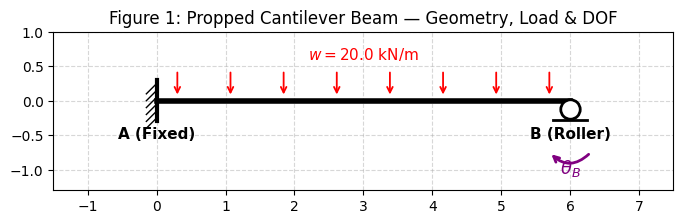

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，轉角鎖死 $\theta_A=0$，不是未知量；B端是滾支承，可以自由轉動，所以 $\theta_B$ 是**唯一**的未知位移量。這是最基本的一次靜不定結構，是本課程的第一個Case——如果誤把 $\theta_A$ 也當成未知量列進方程式，或漏掉 $\theta_B$，後面的方程式全部會建立在錯的自由度上。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- B端邊界條件（滾支承不傳彎矩） M_BA = 0


【步驟 4】求解聯立方程式 (未知位移量)


**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，所以先看符號解能清楚看出這個特性）：

**② 代入 EI 數值**（EI = 15000.0，方便直接跟 anastruct、OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）：


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = -90.000 kN·m
M_{BA} = 0.000 kN·m

-> R_A (kN, 固定端反力) = 75.000
-> R_B (kN, 滾支承反力) = 45.000


{'moments': {'M_{AB}': -90.0, 'M_{BA}': 0.0},
 'reactions': {'R_A (kN, 固定端反力)': 75.0, 'R_B (kN, 滾支承反力)': 45.0},
 'solution': {theta_B: -90.0/EI}}

In [4]:
problem = PropChedCantileverProblem(L=6.0, w=20.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 3b. 教學講義輸出（只有五張圖：結構受力圖／剪力圖／彎矩圖／拉力側標註圖／變形圖，不含文字推導跟評分要點）

### a. 結構受力圖

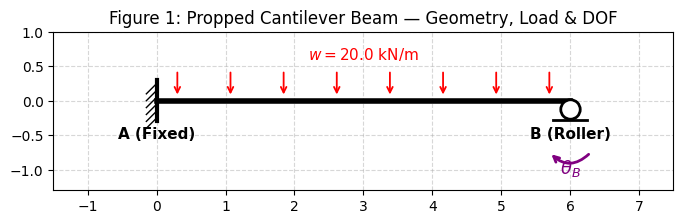

### b. 剪力圖 (SFD)

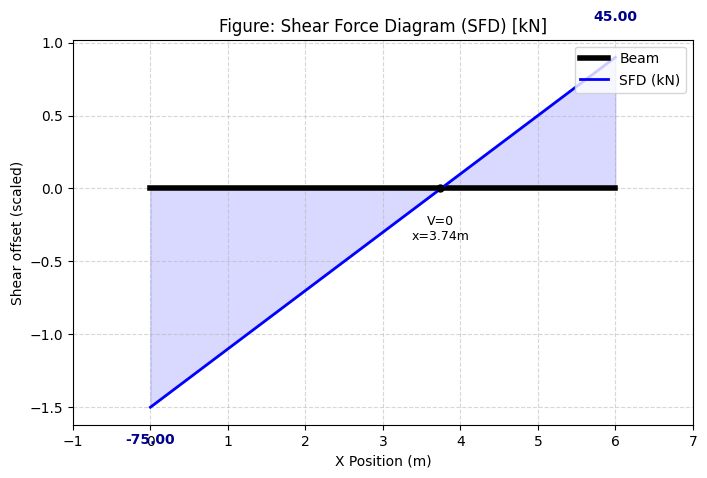

### c. 彎矩圖 (BMD)

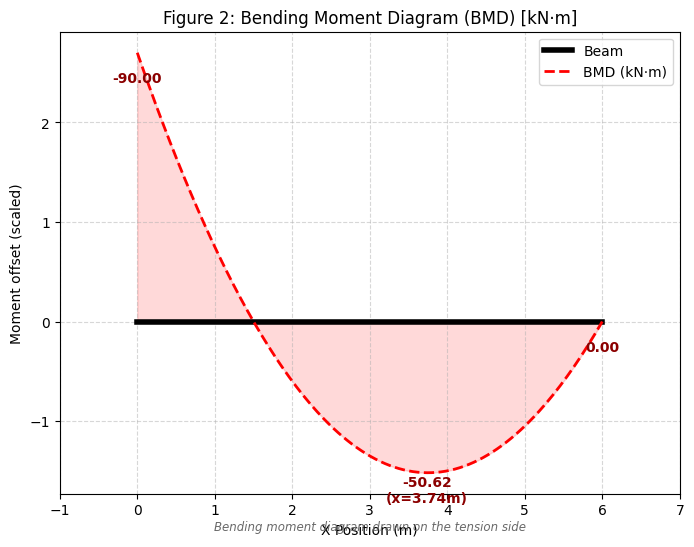

### d. 拉力側標註圖

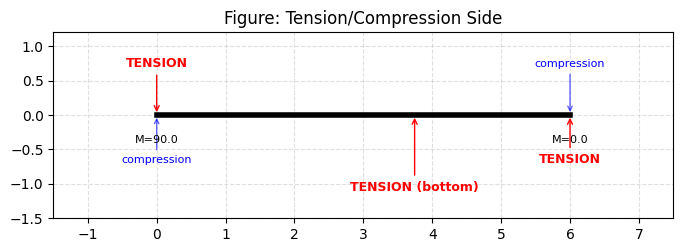

### e. 變形圖

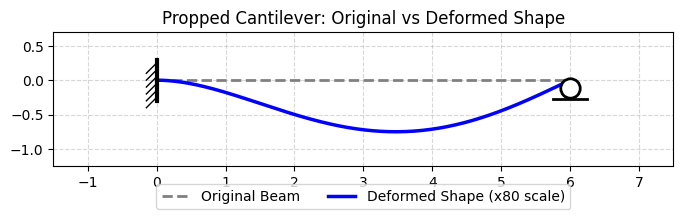

In [5]:
solver.print_teaching_handout()

## 4. anastruct 獨立建模驗證

A端反力: {'id': 1, 'Fx': np.float64(-7.347880794884118e-15), 'Fy': np.float64(-74.99999250000374), 'Tz': np.float64(-89.99995500002248), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
B端反力: {'id': 2, 'Fx': np.float64(0.0), 'Fy': np.float64(-45.00000749999626), 'Tz': np.float64(0.0), 'ux': np.float64(2.2043642384652356e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.005999997000001495)}


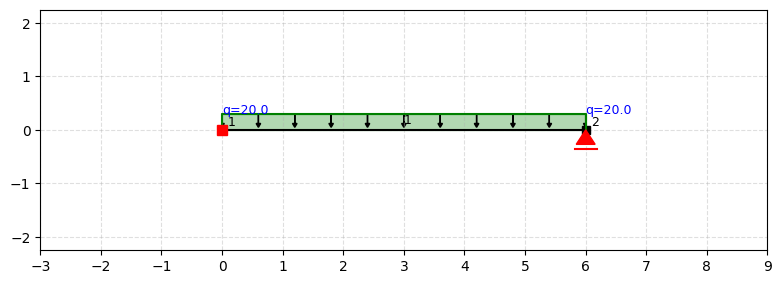

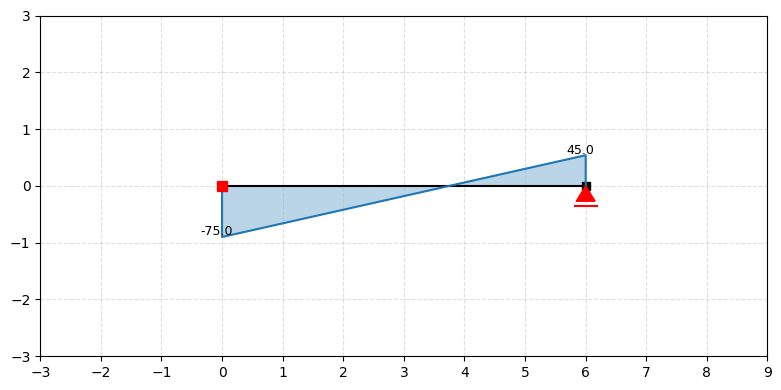

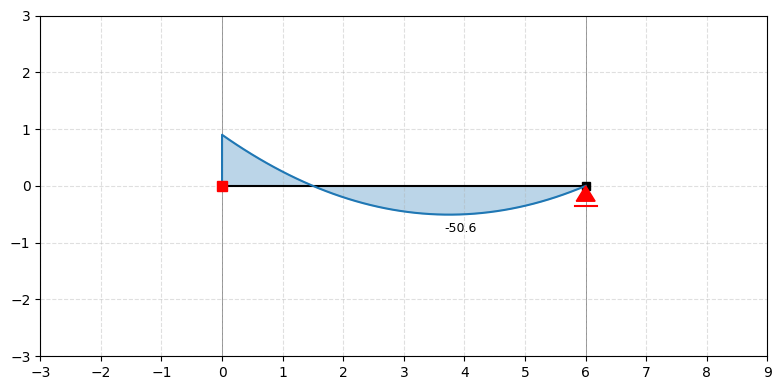

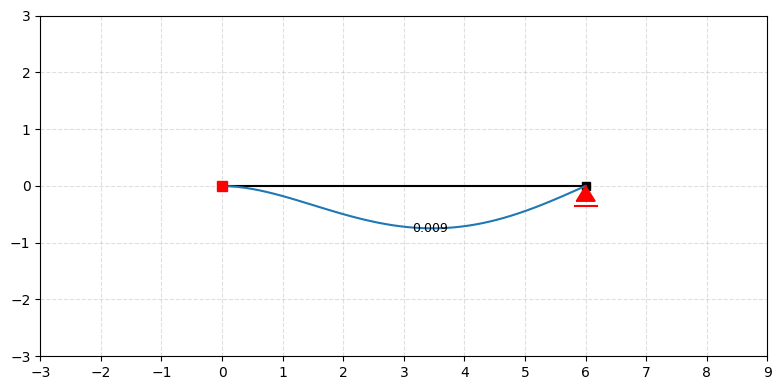

In [6]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L, w = 6.0, 20.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [L, 0]])
ss.add_support_fixed(node_id=1)
ss.add_support_roll(node_id=2, direction='x')
ss.q_load(element_id=1, q=-w)
ss.solve()

print("A端反力:", ss.get_node_results_system(1))
print("B端反力:", ss.get_node_results_system(2))

def apply_grid(fig, y_lines=()):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for y in y_lines:
        ax.axhline(y, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(8, 3))
apply_grid(fig_s)
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(8, 4))
apply_grid(fig_v)
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(8, 4))
ax = fig_m.axes[0]
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', lw=0.6, zorder=0)
ax.axvline(L, color='gray', lw=0.6, zorder=0)
plt.show()

fig_d = ss.show_displacement(show=False, factor=80, figsize=(8, 4))
apply_grid(fig_d)
plt.show()

## 5. 剪力交叉檢查

In [7]:
m_ab, m_ba = -90.0, 0.0
V0_predict = member_shear_curve(0.0, L, w, -m_ab, m_ba)
VL_predict = member_shear_curve(L, L, w, -m_ab, m_ba)
print(f"我們框架推算剪力: V(0)={V0_predict:.3f}  V(L)={VL_predict:.3f}")

el = ss.element_map[1]
print(f"anastruct 實際剪力: V(0)={el.shear_force[0]:.3f}  V(L)={el.shear_force[-1]:.3f}")

assert abs(V0_predict - el.shear_force[0]) < 0.01, "剪力對不上!"
assert abs(VL_predict - el.shear_force[-1]) < 0.01, "剪力對不上!"
print("\n剪力交叉檢查通過 ✓")

我們框架推算剪力: V(0)=-75.000  V(L)=45.000
anastruct 實際剪力: V(0)=-75.000  V(L)=45.000

剪力交叉檢查通過 ✓
